In [1]:
import numpy as np
import scanpy as sc

In [2]:
adata = sc.read_h5ad("../../data/ebdata.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 8659 × 16245
    obs: 'A1BG (ENSG00000121410)', 'A1BG-AS1 (ENSG00000268895)', 'A2M (ENSG00000175899)', 'A2M-AS1 (ENSG00000245105)', 'A4GALT (ENSG00000128274)', 'AAAS (ENSG00000094914)', 'AACS (ENSG00000081760)', 'AADAT (ENSG00000109576)', 'AAED1 (ENSG00000158122)', 'AAGAB (ENSG00000103591)', 'AAK1 (ENSG00000115977)', 'AAMDC (ENSG00000087884)', 'AAMP (ENSG00000127837)', 'AANAT (ENSG00000129673)', 'AAR2 (ENSG00000131043)', 'AARD (ENSG00000205002)', 'AARS (ENSG00000090861)', 'AARS2 (ENSG00000124608)', 'AARSD1 (ENSG00000266967)', 'AASDH (ENSG00000157426)', 'AASDHPPT (ENSG00000149313)', 'AASS (ENSG00000008311)', 'AATF (ENSG00000275700)', 'AATK (ENSG00000181409)', 'ABAT (ENSG00000183044)', 'ABCA1 (ENSG00000165029)', 'ABCA2 (ENSG00000107331)', 'ABCA3 (ENSG00000167972)', 'ABCA5 (ENSG00000154265)', 'ABCA7 (ENSG00000064687)', 'ABCA8 (ENSG00000141338)', 'ABCA9 (ENSG00000154258)', 'ABCB10 (ENSG00000135776)', 'ABCB4 (ENSG00000005471)', 'ABCB5 (ENSG00000004846)',

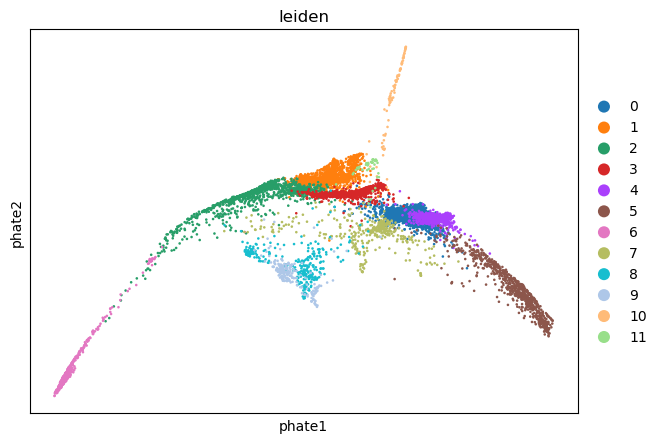

In [4]:
sc.pl.scatter(adata, basis="phate", color="leiden")

In [5]:
adata.uns["iroot"] = np.flatnonzero(adata.obs["leiden"] == "7")[0]

In [6]:
sc.tl.dpt(adata)

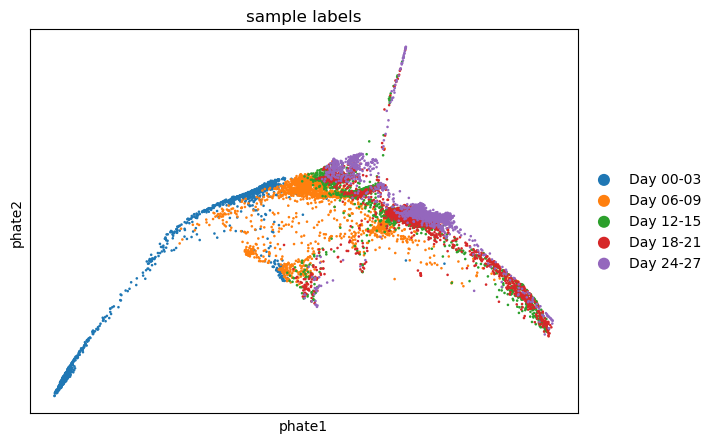

In [7]:
sc.pl.scatter(adata, basis="phate", color="sample_labels")

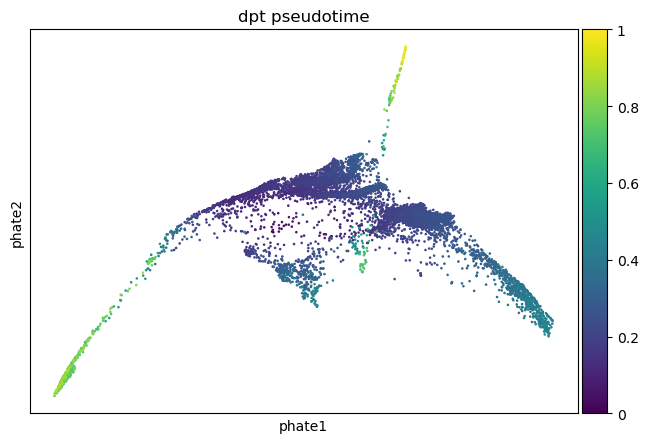

In [8]:
sc.pl.scatter(adata, basis="phate", color="dpt_pseudotime")

In [9]:
# 1d PHATE
import phate

phate_op = phate.PHATE(n_components=1, random_state=42)
oned_embed = phate_op.fit_transform(adata.X)

Calculating PHATE...
  Running PHATE on 8659 observations and 16245 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 14.99 seconds.
    Calculating KNN search...


d:\develop\anaconda\envs\scprep\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


    Calculated KNN search in 2.51 seconds.
    Calculating affinities...
    Calculated affinities in 2.02 seconds.
  Calculated graph and diffusion operator in 19.53 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 0.77 seconds.
    Calculating KMeans...
    Calculated KMeans in 1.93 seconds.
  Calculated landmark operator in 2.70 seconds.
  Calculating optimal t...
    Automatically selected t = 13
  Calculated optimal t in 4.11 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.38 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 5.03 seconds.
Calculated PHATE in 32.27 seconds.


In [10]:
adata.obs["1d-phate"] = oned_embed

In [11]:
adata.obsm["X_phate_time"] = np.stack([adata.obs["dpt_pseudotime"], adata.obs["1d-phate"]], axis=1)

In [12]:
adata.obsm["X_phate_real_time"] = np.stack(
    [
        adata.obs["sample_labels"].cat.codes + np.random.randn(adata.shape[0]) * 0.2,
        adata.obs["1d-phate"],
    ],
    axis=1,
)

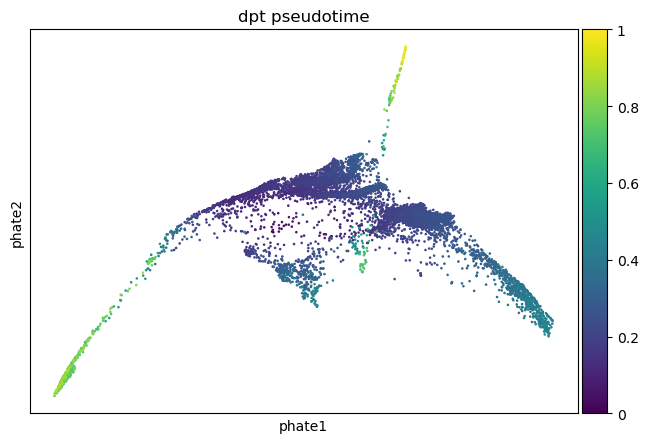

In [13]:
sc.pl.scatter(adata, basis="phate", color="dpt_pseudotime")

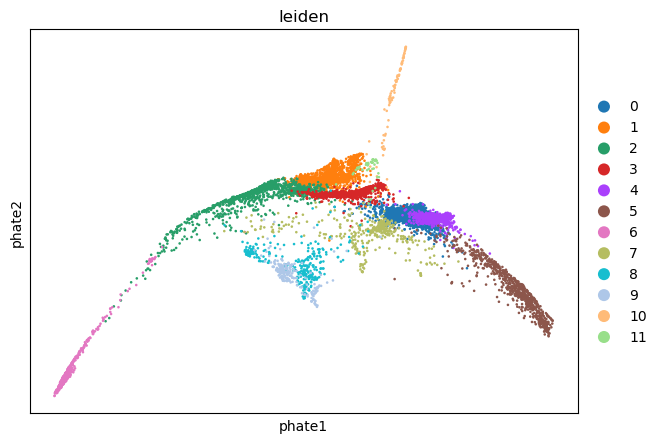

In [14]:
sc.pl.scatter(adata, basis="phate", color="leiden")

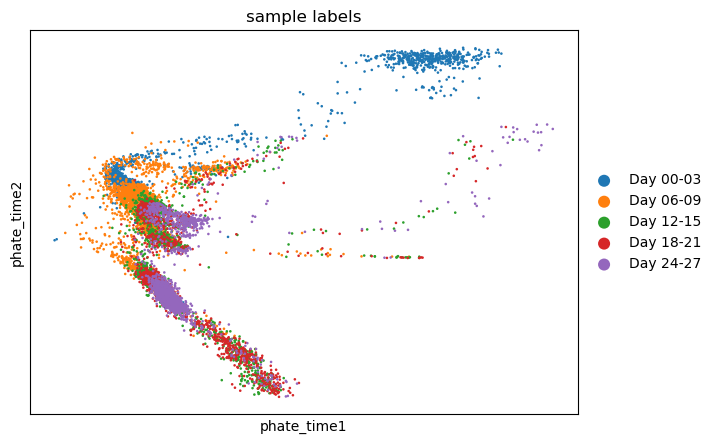

In [15]:
sc.pl.scatter(adata, basis="phate_time", color="sample_labels")

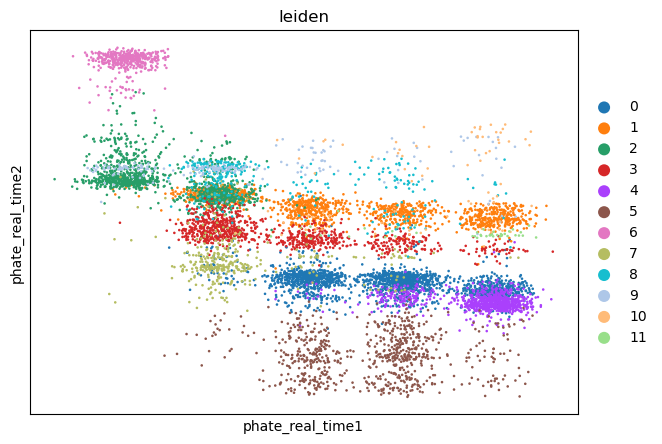

In [16]:
sc.pl.scatter(adata, basis="phate_real_time", color="leiden")

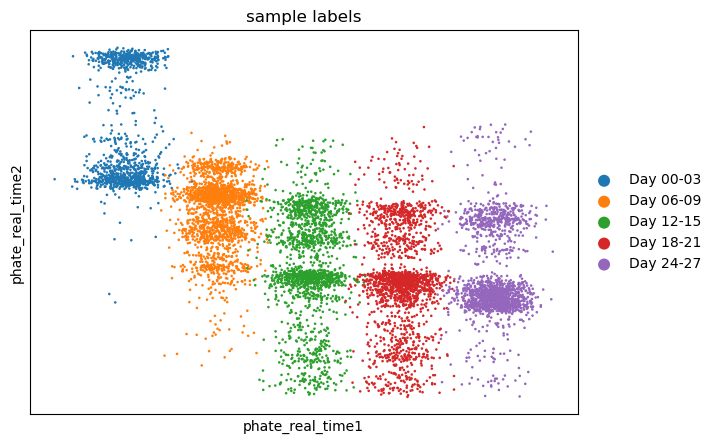

In [17]:
sc.pl.scatter(adata, basis="phate_real_time", color="sample_labels")

In [19]:
adata.write_h5ad(
    "../../data/ebdata_v2.h5ad", compression="gzip"
)

In [20]:
adata = sc.read_h5ad("../../data/ebdata_v2.h5ad")

In [21]:
oned = adata.obs["1d-phate"]
oned = (oned - oned.mean()) / oned.std()
oned
adata.obs["1d-phate-normalized"] = oned
adata.obsm["X_phate_normalized"] = np.stack(
    [
        adata.obs["1d-phate-normalized"],
        adata.obs["sample_labels"].cat.codes + np.random.randn(adata.shape[0]) * 0.2,
    ],
    axis=1,
)

In [23]:
adata.write_h5ad(
    "../../data/ebdata_v3.h5ad", compression="gzip"
)

In [24]:
adata

AnnData object with n_obs × n_vars = 8659 × 16245
    obs: 'A1BG (ENSG00000121410)', 'A1BG-AS1 (ENSG00000268895)', 'A2M (ENSG00000175899)', 'A2M-AS1 (ENSG00000245105)', 'A4GALT (ENSG00000128274)', 'AAAS (ENSG00000094914)', 'AACS (ENSG00000081760)', 'AADAT (ENSG00000109576)', 'AAED1 (ENSG00000158122)', 'AAGAB (ENSG00000103591)', 'AAK1 (ENSG00000115977)', 'AAMDC (ENSG00000087884)', 'AAMP (ENSG00000127837)', 'AANAT (ENSG00000129673)', 'AAR2 (ENSG00000131043)', 'AARD (ENSG00000205002)', 'AARS (ENSG00000090861)', 'AARS2 (ENSG00000124608)', 'AARSD1 (ENSG00000266967)', 'AASDH (ENSG00000157426)', 'AASDHPPT (ENSG00000149313)', 'AASS (ENSG00000008311)', 'AATF (ENSG00000275700)', 'AATK (ENSG00000181409)', 'ABAT (ENSG00000183044)', 'ABCA1 (ENSG00000165029)', 'ABCA2 (ENSG00000107331)', 'ABCA3 (ENSG00000167972)', 'ABCA5 (ENSG00000154265)', 'ABCA7 (ENSG00000064687)', 'ABCA8 (ENSG00000141338)', 'ABCA9 (ENSG00000154258)', 'ABCB10 (ENSG00000135776)', 'ABCB4 (ENSG00000005471)', 'ABCB5 (ENSG00000004846)',

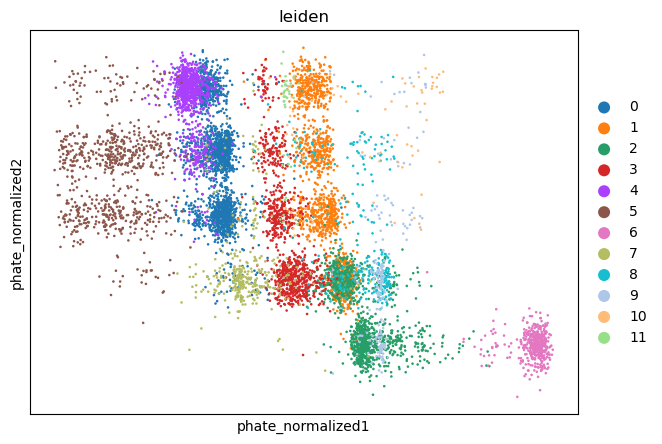

In [25]:
sc.pl.scatter(adata, basis="phate_normalized", color="leiden")

In [26]:
adata_sub = adata[~adata.obs["leiden"].isin(["7"])]

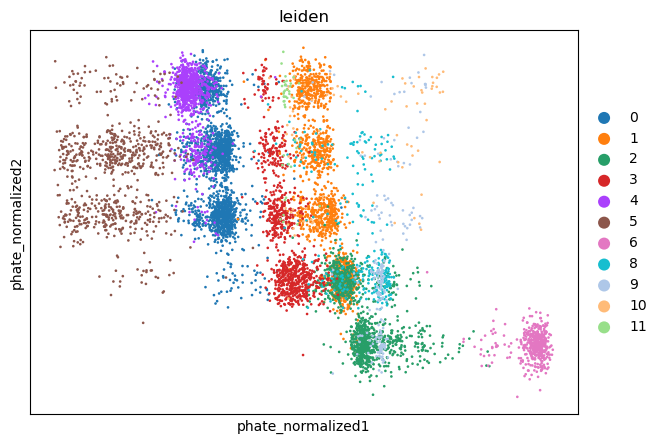

In [27]:
sc.pl.scatter(adata_sub, basis="phate_normalized", color="leiden")

In [28]:
adata_sub

View of AnnData object with n_obs × n_vars = 8290 × 16245
    obs: 'A1BG (ENSG00000121410)', 'A1BG-AS1 (ENSG00000268895)', 'A2M (ENSG00000175899)', 'A2M-AS1 (ENSG00000245105)', 'A4GALT (ENSG00000128274)', 'AAAS (ENSG00000094914)', 'AACS (ENSG00000081760)', 'AADAT (ENSG00000109576)', 'AAED1 (ENSG00000158122)', 'AAGAB (ENSG00000103591)', 'AAK1 (ENSG00000115977)', 'AAMDC (ENSG00000087884)', 'AAMP (ENSG00000127837)', 'AANAT (ENSG00000129673)', 'AAR2 (ENSG00000131043)', 'AARD (ENSG00000205002)', 'AARS (ENSG00000090861)', 'AARS2 (ENSG00000124608)', 'AARSD1 (ENSG00000266967)', 'AASDH (ENSG00000157426)', 'AASDHPPT (ENSG00000149313)', 'AASS (ENSG00000008311)', 'AATF (ENSG00000275700)', 'AATK (ENSG00000181409)', 'ABAT (ENSG00000183044)', 'ABCA1 (ENSG00000165029)', 'ABCA2 (ENSG00000107331)', 'ABCA3 (ENSG00000167972)', 'ABCA5 (ENSG00000154265)', 'ABCA7 (ENSG00000064687)', 'ABCA8 (ENSG00000141338)', 'ABCA9 (ENSG00000154258)', 'ABCB10 (ENSG00000135776)', 'ABCB4 (ENSG00000005471)', 'ABCB5 (ENSG000000

In [29]:
del adata_sub.uns["leiden_colors"]
sc.tl.leiden(adata_sub, resolution=0.25)

C:\Users\16592\AppData\Local\Temp\ipykernel_6196\2972002292.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sub, resolution=0.25)
d:\develop\anaconda\envs\scprep\lib\site-packages\scanpy\tools\_leiden.py:197: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(


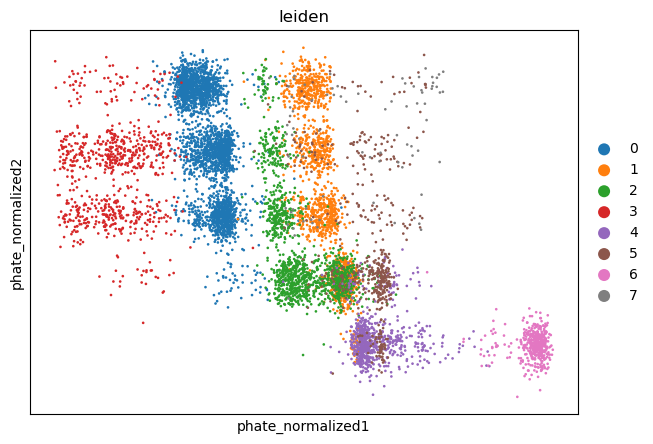

In [30]:
sc.pl.scatter(adata_sub, basis="phate_normalized", color="leiden")

In [31]:
adata_sub.write_h5ad(
    "../../data/ebdata_no_day_zero_v3.h5ad",
    compression="gzip",
)

In [32]:
adata

AnnData object with n_obs × n_vars = 8659 × 16245
    obs: 'A1BG (ENSG00000121410)', 'A1BG-AS1 (ENSG00000268895)', 'A2M (ENSG00000175899)', 'A2M-AS1 (ENSG00000245105)', 'A4GALT (ENSG00000128274)', 'AAAS (ENSG00000094914)', 'AACS (ENSG00000081760)', 'AADAT (ENSG00000109576)', 'AAED1 (ENSG00000158122)', 'AAGAB (ENSG00000103591)', 'AAK1 (ENSG00000115977)', 'AAMDC (ENSG00000087884)', 'AAMP (ENSG00000127837)', 'AANAT (ENSG00000129673)', 'AAR2 (ENSG00000131043)', 'AARD (ENSG00000205002)', 'AARS (ENSG00000090861)', 'AARS2 (ENSG00000124608)', 'AARSD1 (ENSG00000266967)', 'AASDH (ENSG00000157426)', 'AASDHPPT (ENSG00000149313)', 'AASS (ENSG00000008311)', 'AATF (ENSG00000275700)', 'AATK (ENSG00000181409)', 'ABAT (ENSG00000183044)', 'ABCA1 (ENSG00000165029)', 'ABCA2 (ENSG00000107331)', 'ABCA3 (ENSG00000167972)', 'ABCA5 (ENSG00000154265)', 'ABCA7 (ENSG00000064687)', 'ABCA8 (ENSG00000141338)', 'ABCA9 (ENSG00000154258)', 'ABCB10 (ENSG00000135776)', 'ABCB4 (ENSG00000005471)', 'ABCB5 (ENSG00000004846)',

In [33]:
X = adata.obs["1d-phate-normalized"]
t = adata.obs["sample_labels"].cat.codes

In [34]:
X_sub = X[t.isin([3, 4])]
t_sub = t[t.isin([3, 4])]

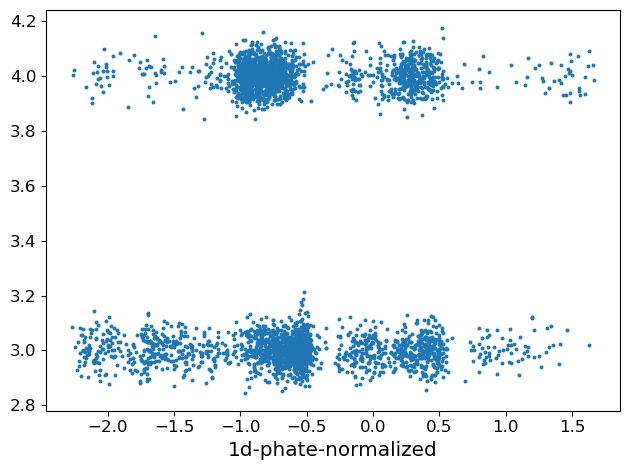

<Axes: xlabel='1d-phate-normalized'>

In [36]:
import scprep
scprep.plot.scatter(X_sub, t_sub + 0.05 * np.random.randn(*t_sub.shape))

<Axes: xlabel='1d-phate-normalized', ylabel='Density'>

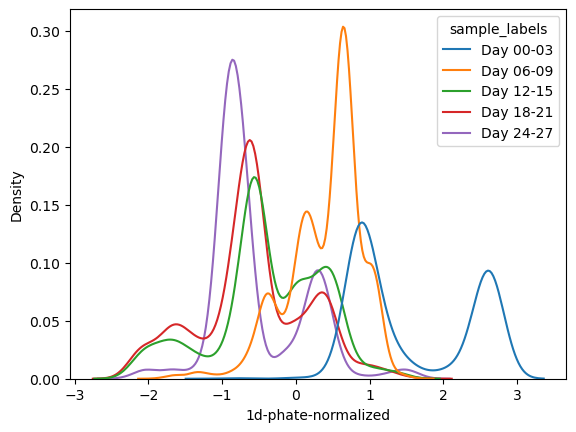

In [37]:
import seaborn as sns

sns.kdeplot(data=adata.obs, x="1d-phate-normalized", hue="sample_labels")

In [40]:
# 补充安装
!pip install pot

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


In [48]:
import ot as pot
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix

x0 = X_sub[t_sub == 3].values[:100, None]
x1 = X_sub[t_sub == 4].values[:100, None]
m = x0.shape[0]
n = x1.shape[0]
a = np.ones(m) / m
b = np.ones(n) / n

M = distance_matrix(x0, x1)

In [49]:
%%time
final_gamma = 1e-8
t, t_list, g_list = pot.regpath.regularization_path(
    a, b, M, reg=final_gamma, semi_relaxed=True, itmax=100
)

maximum iteration has been reached !
CPU times: total: 1.56 s
Wall time: 1.57 s


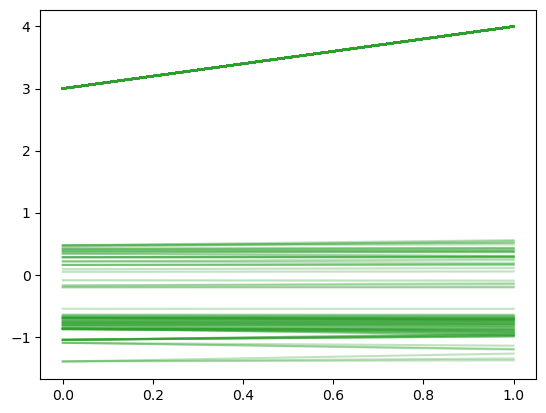

In [50]:
t2 = pot.regpath.compute_transport_plan(1, g_list, t_list).reshape(m, n)
if t2.sum() > 0:
    t2 = t2 / t2.max()
for i in range(m):
    for j in range(n):
        if t2[i, j] > 0:
            plt.plot([[x0[i, 0], 3], [x1[j, 0], 4]], color="C2", alpha=t2[i, j] * 0.3)

In [51]:
t2

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

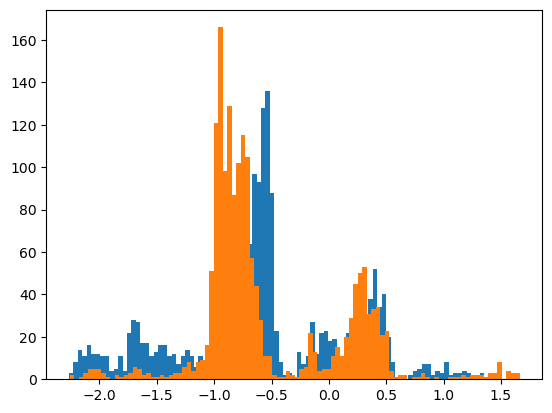

In [52]:
import matplotlib.pyplot as plt

plt.hist(X_sub[t_sub == 3], bins=100)
cax = plt.hist(X_sub[t_sub == 4], bins=100)

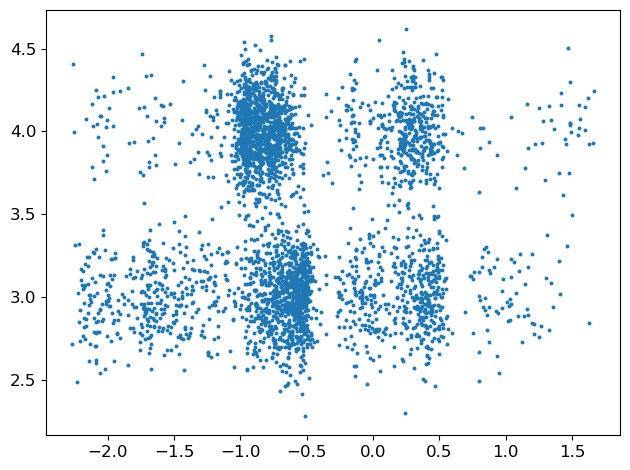

<Axes: >

In [53]:
import scprep

scprep.plot.scatter2d(
    adata[adata.obs["sample_labels"].cat.codes.isin([3, 4])].obsm["X_phate_normalized"]
)